In [3]:
from google.colab import files

uploaded = files.upload()

Saving customers_silver.xlsx to customers_silver (1).xlsx


In [4]:
from google.colab import files

uploaded = files.upload()

Saving order_items_silver.xlsx to order_items_silver.xlsx
Saving orders_enriched_silver.xlsx to orders_enriched_silver.xlsx


In [5]:
from google.colab import files

uploaded = files.upload()

Saving products_silver.xlsx to products_silver.xlsx


In [10]:
import os

print(os.listdir("/content"))

['.config', 'orders_enriched_silver.xlsx', 'order_items_silver.xlsx', 'products_silver.xlsx', 'customers_silver (1).xlsx', 'customers_silver.xlsx', 'sample_data']


In [11]:
import pandas as pd

customers = pd.read_excel("/content/customers_silver.xlsx")


print("Đọc file thành công!")

Đọc file thành công!


In [12]:
import pandas as pd

orders = pd.read_excel("/content/orders_enriched_silver.xlsx")


print("Đọc file thành công!")

Đọc file thành công!


In [13]:
import pandas as pd

order_items = pd.read_excel("/content/order_items_silver.xlsx")


print("Đọc file thành công!")

Đọc file thành công!


In [14]:
import pandas as pd

products = pd.read_excel("/content/products_silver.xlsx")

print("Đọc file thành công!")

Đọc file thành công!


In [15]:
print("===== DANH SÁCH NHÂN VIÊN =====")
print(orders["sales_employee_name"].value_counts(dropna=False))

print("\n===== TRẠNG THÁI ĐƠN HÀNG =====")
print(orders["order_status"].value_counts(dropna=False))

===== DANH SÁCH NHÂN VIÊN =====
sales_employee_name
Bùi Minh Quân       6610
Bùi Ngọc Lan        6605
Võ Quốc Trang       6551
Nguyễn Hữu Bình     6515
Đỗ Anh Khánh        6511
                    ... 
Phạm Văn Bình       3129
Ngô Đức Nam         3117
Dương Minh Giang    3113
Nguyễn Đức Bình     3097
Võ Anh Cường        3084
Name: count, Length: 192, dtype: int64

===== TRẠNG THÁI ĐƠN HÀNG =====
order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275
Name: count, dtype: int64


In [18]:
# Đọc file chi tiết đơn hàng nếu chưa có
order_items = pd.read_excel("/content/order_items_silver.xlsx")

# Ghép đơn hàng với chi tiết sản phẩm
sales = orders.merge(
    order_items,
    on="order_id",
    how="inner"
)

# Tính doanh thu
sales["revenue"] = (
    sales["quantity"] * sales["unit_price"]
    - sales["discount_amount"].fillna(0)
)

# Chỉ lấy đơn hàng thành công
sales_success = sales[
    sales["order_status"].str.lower() == "delivered"
].copy()

# Thống kê theo nhân viên
employee_sales = sales_success.groupby(
    "sales_employee_name"
).agg(
    Tong_doanh_thu=("revenue", "sum"),
    So_hoa_don=("order_id", "nunique")
).reset_index()

# Sắp xếp doanh thu giảm dần
employee_sales = employee_sales.sort_values(
    "Tong_doanh_thu",
    ascending=False
)

print("===== DOANH THU VÀ SỐ HÓA ĐƠN THEO NHÂN VIÊN =====")
print(employee_sales.to_string(index=False))

===== DOANH THU VÀ SỐ HÓA ĐƠN THEO NHÂN VIÊN =====
sales_employee_name  Tong_doanh_thu  So_hoa_don
      Bùi Minh Quân    130165967.88        5335
       Bùi Ngọc Lan    129585705.49        5277
       Phan Anh Lan    128463759.71        5250
       Đỗ Anh Khánh    126960003.14        5244
    Nguyễn Hữu Bình    125045180.62        5244
      Phan Thị Uyên    123774523.57        5094
     Hoàng Quốc Mai    123425524.35        5139
      Võ Quốc Trang    123225621.17        5193
     Phạm Thanh Mai     66103009.31        2623
        Lê Hữu Dũng     65889737.24        2637
     Lê Thanh Trang     65849309.55        2635
   Trần Thanh Giang     65797886.80        2655
       Dương Thị Hà     65685123.13        2645
        Lê Đức Uyên     65611993.66        2630
         Đỗ Ngọc Vy     65583064.89        2628
         Vũ Anh Yến     65504037.91        2664
         Bùi Thị Vy     65315578.79        2654
      Huỳnh Đức Nam     65248793.93        2642
      Dương Anh Mai     65114191.93  

In [19]:
# Tổng số hóa đơn đã xử lý của từng nhân viên
employee_total = orders.groupby(
    "sales_employee_name"
).agg(
    Tong_hoa_don_xu_ly=("order_id", "nunique")
).reset_index()

# Ghép với bảng doanh thu
employee_kpi = employee_sales.merge(
    employee_total,
    on="sales_employee_name",
    how="left"
)

# Tính tỷ lệ hoàn thành
employee_kpi["Ty_le_hoan_thanh"] = (
    employee_kpi["So_hoa_don"]
    / employee_kpi["Tong_hoa_don_xu_ly"]
    * 100
)

# Tính doanh thu trung bình trên mỗi hóa đơn thành công
employee_kpi["Doanh_thu_TB_hoa_don"] = (
    employee_kpi["Tong_doanh_thu"]
    / employee_kpi["So_hoa_don"]
)

# Sắp xếp theo doanh thu
employee_kpi = employee_kpi.sort_values(
    "Tong_doanh_thu",
    ascending=False
)

print("===== KPI NHÂN VIÊN =====")
print(
    employee_kpi[
        [
            "sales_employee_name",
            "Tong_hoa_don_xu_ly",
            "So_hoa_don",
            "Ty_le_hoan_thanh",
            "Tong_doanh_thu",
            "Doanh_thu_TB_hoa_don"
        ]
    ].to_string(index=False)
)

===== KPI NHÂN VIÊN =====
sales_employee_name  Tong_hoa_don_xu_ly  So_hoa_don  Ty_le_hoan_thanh  Tong_doanh_thu  Doanh_thu_TB_hoa_don
      Bùi Minh Quân                6610        5335         80.711044    130165967.88          24398.494448
       Bùi Ngọc Lan                6605        5277         79.894020    129585705.49          24556.699922
       Phan Anh Lan                6472        5250         81.118665    128463759.71          24469.287564
       Đỗ Anh Khánh                6511        5244         80.540624    126960003.14          24210.526915
    Nguyễn Hữu Bình                6515        5244         80.491174    125045180.62          23845.381506
      Phan Thị Uyên                6398        5094         79.618631    123774523.57          24298.100426
     Hoàng Quốc Mai                6431        5139         79.909812    123425524.35          24017.420578
      Võ Quốc Trang                6551        5193         79.270340    123225621.17          23729.177965
  

In [20]:
#ìm Top và Underperformers

# Top 10 nhân viên theo doanh thu
top_10 = employee_kpi.sort_values(
    "Tong_doanh_thu",
    ascending=False
).head(10)

# Bottom 10 nhân viên theo doanh thu
bottom_10 = employee_kpi.sort_values(
    "Tong_doanh_thu",
    ascending=True
).head(10)

print("===== TOP 10 NHÂN VIÊN =====")
print(
    top_10[
        [
            "sales_employee_name",
            "Tong_hoa_don_xu_ly",
            "So_hoa_don",
            "Ty_le_hoan_thanh",
            "Tong_doanh_thu",
            "Doanh_thu_TB_hoa_don"
        ]
    ].to_string(index=False)
)

print("\n===== BOTTOM 10 NHÂN VIÊN =====")
print(
    bottom_10[
        [
            "sales_employee_name",
            "Tong_hoa_don_xu_ly",
            "So_hoa_don",
            "Ty_le_hoan_thanh",
            "Tong_doanh_thu",
            "Doanh_thu_TB_hoa_don"
        ]
    ].to_string(index=False)
)

===== TOP 10 NHÂN VIÊN =====
sales_employee_name  Tong_hoa_don_xu_ly  So_hoa_don  Ty_le_hoan_thanh  Tong_doanh_thu  Doanh_thu_TB_hoa_don
      Bùi Minh Quân                6610        5335         80.711044    130165967.88          24398.494448
       Bùi Ngọc Lan                6605        5277         79.894020    129585705.49          24556.699922
       Phan Anh Lan                6472        5250         81.118665    128463759.71          24469.287564
       Đỗ Anh Khánh                6511        5244         80.540624    126960003.14          24210.526915
    Nguyễn Hữu Bình                6515        5244         80.491174    125045180.62          23845.381506
      Phan Thị Uyên                6398        5094         79.618631    123774523.57          24298.100426
     Hoàng Quốc Mai                6431        5139         79.909812    123425524.35          24017.420578
      Võ Quốc Trang                6551        5193         79.270340    123225621.17          23729.177965

In [22]:
# Chuyển order_date sang dạng ngày tháng
sales_success["order_date"] = pd.to_datetime(
    sales_success["order_date"],
    errors="coerce"
)

# Kiểm tra kiểu dữ liệu
print("Kiểu dữ liệu order_date:")
print(sales_success["order_date"].dtype)

# Tạo cột tháng
sales_success["Thang"] = (
    sales_success["order_date"]
    .dt.to_period("M")
    .astype(str)
)

# Tính doanh thu theo tháng và nhân viên
employee_monthly = sales_success.groupby(
    ["Thang", "sales_employee_name"]
).agg(
    Doanh_thu=("revenue", "sum"),
    So_hoa_don=("order_id", "nunique")
).reset_index()

print("\n===== DOANH THU THEO THÁNG CỦA NHÂN VIÊN =====")
print(employee_monthly.head(20).to_string(index=False))

Kiểu dữ liệu order_date:
datetime64[ns]

===== DOANH THU THEO THÁNG CỦA NHÂN VIÊN =====
  Thang sales_employee_name    Doanh_thu  So_hoa_don
1970-01         Bùi Anh Sơn  62624943.42        2620
1970-01          Bùi Anh Vy  62198990.47        2628
1970-01        Bùi Gia Bình  61221387.17        2572
1970-01       Bùi Minh Bình  64280103.17        2623
1970-01        Bùi Minh Lan  62391330.43        2625
1970-01       Bùi Minh Quân 130165967.88        5335
1970-01      Bùi Minh Trang  62699685.35        2634
1970-01        Bùi Ngọc Lan 129585705.49        5277
1970-01        Bùi Thị Dũng  61664141.84        2554
1970-01         Bùi Thị Mai  61042540.40        2487
1970-01          Bùi Thị Vy  65315578.79        2654
1970-01         Bùi Thị Yến  64383129.28        2595
1970-01        Bùi Đức Uyên  63119895.32        2635
1970-01     Dương Anh Giang  62606984.85        2596
1970-01      Dương Anh Hùng  64620740.21        2619
1970-01       Dương Anh Mai  65114191.93        2671
1970-01    

In [28]:
import pandas as pd

# 1. Đọc lại file orders gốc
orders = pd.read_excel(
    "/content/orders_enriched_silver.xlsx"
)

# 2. Chuyển ngày Excel Serial sang ngày thực tế
orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    unit="D",
    origin="1899-12-30"
)

# 3. Đọc lại order_items
order_items = pd.read_excel(
    "/content/order_items_silver.xlsx"
)

# 4. Ghép orders với order_items
sales = orders.merge(
    order_items,
    on="order_id",
    how="inner"
)

# 5. Tính doanh thu
sales["revenue"] = (
    sales["quantity"] * sales["unit_price"]
    - sales["discount_amount"].fillna(0)
)

# 6. Chỉ lấy hóa đơn đã giao thành công
sales_success = sales[
    sales["order_status"].str.lower() == "delivered"
].copy()

# 7. Tạo cột tháng
sales_success["Thang"] = (
    sales_success["order_date"]
    .dt.to_period("M")
    .astype(str)
)

# 8. Tính doanh thu theo tháng và nhân viên
employee_monthly = sales_success.groupby(
    ["Thang", "sales_employee_name"]
).agg(
    Doanh_thu=("revenue", "sum"),
    So_hoa_don=("order_id", "nunique")
).reset_index()

# 9. Kiểm tra
print("===== KIỂM TRA NGÀY =====")
print(sales_success["order_date"].head())

print("\n===== DOANH THU THEO THÁNG =====")
print(employee_monthly.head(20).to_string(index=False))

===== KIỂM TRA NGÀY =====
0   2012-07-04
2   2012-07-04
3   2012-07-04
4   2012-07-06
5   2012-07-06
Name: order_date, dtype: datetime64[ns]

===== DOANH THU THEO THÁNG =====
  Thang sales_employee_name  Doanh_thu  So_hoa_don
2012-07         Bùi Anh Sơn  323523.86          17
2012-07          Bùi Anh Vy  634224.38          24
2012-07        Bùi Gia Bình  359659.35          19
2012-07       Bùi Minh Bình  512884.52          26
2012-07        Bùi Minh Lan  381229.37          14
2012-07       Bùi Minh Quân 1100867.85          53
2012-07      Bùi Minh Trang  519748.87          22
2012-07        Bùi Ngọc Lan  975437.82          47
2012-07        Bùi Thị Dũng  606176.46          20
2012-07         Bùi Thị Mai  409232.24          19
2012-07          Bùi Thị Vy  345504.53          15
2012-07         Bùi Thị Yến  641573.40          24
2012-07        Bùi Đức Uyên  485171.98          25
2012-07     Dương Anh Giang  565035.31          23
2012-07      Dương Anh Hùng  625379.21          21
2012-07  

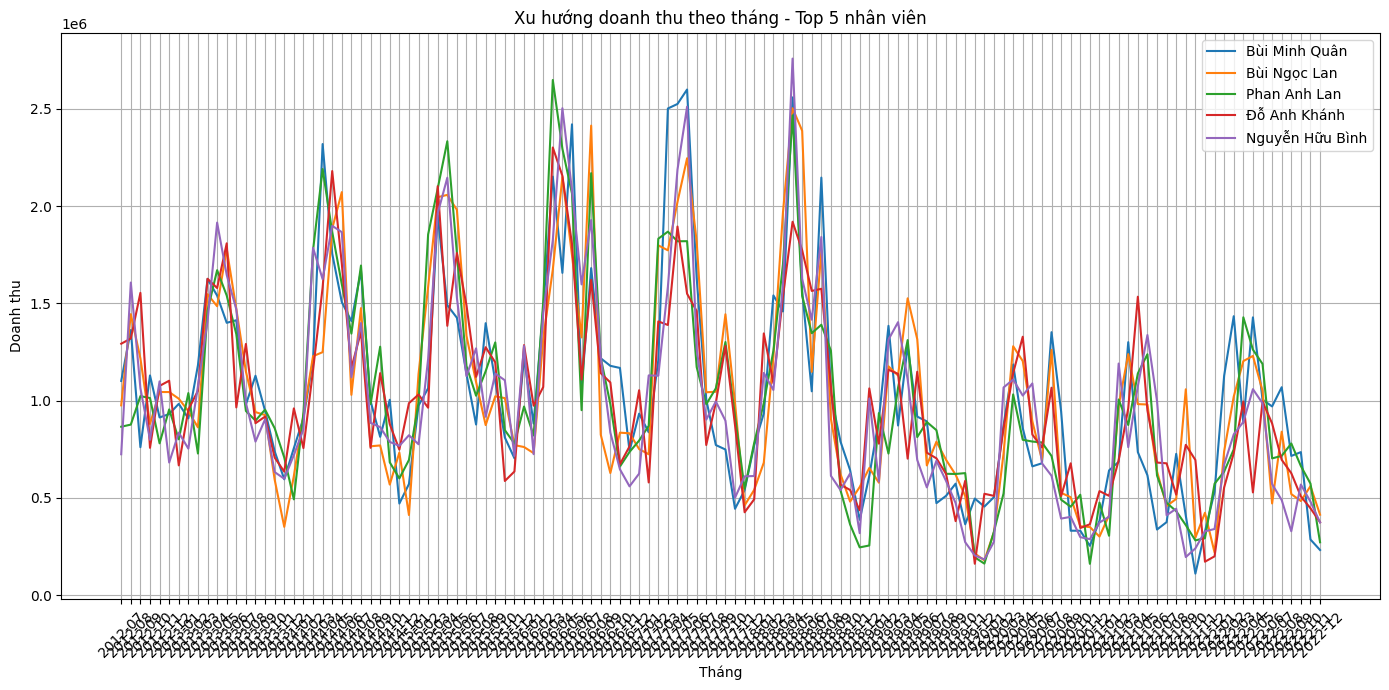

In [29]:
#Vẽ biểu đồ xu hướng Top 5

import matplotlib.pyplot as plt

# Lấy Top 5 nhân viên có tổng doanh thu cao nhất
top5_names = employee_kpi.nlargest(
    5, "Tong_doanh_thu"
)["sales_employee_name"].tolist()

# Lọc dữ liệu theo Top 5
top5_monthly = employee_monthly[
    employee_monthly["sales_employee_name"].isin(top5_names)
].copy()

# Sắp xếp theo thời gian
top5_monthly = top5_monthly.sort_values("Thang")

# Vẽ biểu đồ
plt.figure(figsize=(14, 7))

for employee in top5_names:
    data = top5_monthly[
        top5_monthly["sales_employee_name"] == employee
    ]

    plt.plot(
        data["Thang"],
        data["Doanh_thu"],
        label=employee
    )

plt.title("Xu hướng doanh thu theo tháng - Top 5 nhân viên")
plt.xlabel("Tháng")
plt.ylabel("Doanh thu")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
#Kiểm tra nhận xét của khách hàng

print("Các cột liên quan đến đánh giá/nhận xét:")

for col in orders.columns:
    if any(keyword in col.lower() for keyword in [
        "comment", "review", "rating", "feedback", "satisfaction"
    ]):
        print("-", col)

print("\n20 NHẬN XÉT ĐẦU TIÊN ")

if "comments" in orders.columns:
    print(
        orders["comments"]
        .dropna()
        .head(20)
        .to_string(index=False)
    )
else:
    print("Không tìm thấy cột comments.")

Các cột liên quan đến đánh giá/nhận xét:
- comment

20 NHẬN XÉT ĐẦU TIÊN 
Không tìm thấy cột comments.


In [32]:
#Kiểm tra nội dung đánh giá

print(" 20 NHẬN XÉT KHÁCH HÀNG ")

print(
    orders["comment"]
    .dropna()
    .head(20)
    .to_string(index=False)
)

 20 NHẬN XÉT KHÁCH HÀNG 
Dịch vụ chăm sóc khách hàng chuyên nghiệp, thái...
Dịch vụ ổn định, nhân viên luôn sẵn sàng hỗ trợ...
Khách hàng không có thêm phản hồi về chất lượng...
Phản hồi thắc mắc đầy đủ, hỗ trợ xuyên suốt quá...
    Khách hàng đánh giá mức độ hài lòng ở mức khá.
Tư vấn chi tiết, thái độ chuyên nghiệp và thân ...
Hỗ trợ nhanh chóng, tư vấn rõ ràng, khách hàng ...
Quá trình hỗ trợ diễn ra bình thường, đúng quy ...
Nhân viên giao tiếp tốt, xử lý yêu cầu đúng hẹn...
Quá trình hỗ trợ diễn ra bình thường, đúng quy ...
 Chăm sóc khách hàng tốt, thời gian phản hồi ngắn.
Hỗ trợ nhanh chóng, tư vấn rõ ràng, khách hàng ...
Khách hàng đánh giá cao sự chủ động và trách nh...
Nhân viên giao tiếp tốt, xử lý yêu cầu đúng hẹn...
Phản hồi thắc mắc đầy đủ, hỗ trợ xuyên suốt quá...
Hỗ trợ nhanh chóng, tư vấn rõ ràng, khách hàng ...
Khách hàng không có thêm phản hồi về chất lượng...
    Khách hàng đánh giá mức độ hài lòng ở mức khá.
 Chăm sóc khách hàng tốt, thời gian phản hồi ngắn.
Phản h

In [33]:
#Phân loại đánh giá khách hàng

def danh_gia_thai_do(comment):
    if pd.isna(comment):
        return "Không có đánh giá"

    comment = str(comment).lower()

    # Nhóm tích cực
    tu_khoa_tich_cuc = [
        "chuyên nghiệp",
        "hài lòng",
        "tốt",
        "nhanh chóng",
        "giao tiếp tốt",
        "hỗ trợ tốt",
        "đánh giá cao",
        "chủ động",
        "phản hồi đầy đủ"
    ]

    # Nhóm tiêu cực
    tu_khoa_tieu_cuc = [
        "không hài lòng",
        "chậm",
        "không tốt",
        "phàn nàn",
        "thái độ chưa tốt",
        "hỗ trợ chưa tốt"
    ]

    if any(tu_khoa in comment for tu_khoa in tu_khoa_tieu_cuc):
        return "Tiêu cực"
    elif any(tu_khoa in comment for tu_khoa in tu_khoa_tich_cuc):
        return "Tích cực"
    else:
        return "Trung tính"


# Tạo cột đánh giá
orders["Danh_gia_thai_do"] = orders["comment"].apply(
    danh_gia_thai_do
)

# Thống kê
print("KẾT QUẢ ĐÁNH GIÁ THÁI ĐỘ")

print(
    orders["Danh_gia_thai_do"]
    .value_counts()
)

KẾT QUẢ ĐÁNH GIÁ THÁI ĐỘ
Danh_gia_thai_do
Tích cực      369147
Trung tính    266599
Tiêu cực       11199
Name: count, dtype: int64


In [34]:
# ĐÁNH GIÁ THÁI ĐỘ THEO NHÂN VIÊN

employee_service = orders.groupby(
    "sales_employee_name"
).agg(
    So_danh_gia=("comment", "count"),
    Tich_cuc=("Danh_gia_thai_do", lambda x: (x == "Tích cực").sum()),
    Tieu_cuc=("Danh_gia_thai_do", lambda x: (x == "Tiêu cực").sum()),
    Trung_tinh=("Danh_gia_thai_do", lambda x: (x == "Trung tính").sum())
).reset_index()

# Tỷ lệ đánh giá tích cực
employee_service["Ty_le_tich_cuc"] = (
    employee_service["Tich_cuc"]
    / employee_service["So_danh_gia"]
    * 100
)

# Sắp xếp
employee_service = employee_service.sort_values(
    "Ty_le_tich_cuc",
    ascending=False
)

print("ĐÁNH GIÁ DỊCH VỤ THEO NHÂN VIÊN")

print(
    employee_service.head(20).to_string(index=False)
)

ĐÁNH GIÁ DỊCH VỤ THEO NHÂN VIÊN
sales_employee_name  So_danh_gia  Tich_cuc  Tieu_cuc  Trung_tinh  Ty_le_tich_cuc
      Đặng Văn Phúc         3225      1921        41        1263       59.565891
       Phạm Văn Mai         3274      1944        52        1278       59.376909
     Huỳnh Đức Linh         3318      1960        60        1298       59.071730
       Ngô Gia Uyên         3132      1849        40        1243       59.035760
    Hoàng Hữu Giang         3156      1861        48        1247       58.967047
        Lê Quốc Mai         3201      1880        52        1269       58.731646
      Vũ Thanh Quân         3234      1899        65        1270       58.719852
       Ngô Đức Bình         3250      1907        46        1297       58.676923
       Bùi Gia Bình         3231      1893        49        1289       58.588672
    Nguyễn Minh Mai         3242      1898        51        1293       58.544109
       Vũ Quốc Dũng         3173      1857        51        1265       58.525

In [35]:
# BẢNG KPI TỔNG HỢP NHÂN VIÊN

kpi_final = employee_kpi.merge(
    employee_service[
        [
            "sales_employee_name",
            "So_danh_gia",
            "Tich_cuc",
            "Tieu_cuc",
            "Trung_tinh",
            "Ty_le_tich_cuc"
        ]
    ],
    on="sales_employee_name",
    how="left"
)

# Chọn các cột cần thiết
kpi_final = kpi_final[
    [
        "sales_employee_name",
        "Tong_hoa_don_xu_ly",
        "So_hoa_don",
        "Ty_le_hoan_thanh",
        "Tong_doanh_thu",
        "Doanh_thu_TB_hoa_don",
        "So_danh_gia",
        "Tich_cuc",
        "Tieu_cuc",
        "Ty_le_tich_cuc"
    ]
]

# Sắp xếp theo doanh thu
kpi_final = kpi_final.sort_values(
    "Tong_doanh_thu",
    ascending=False
)

print("===== KPI TỔNG HỢP NHÂN VIÊN =====")

print(
    kpi_final.head(20).to_string(index=False)
)

===== KPI TỔNG HỢP NHÂN VIÊN =====
sales_employee_name  Tong_hoa_don_xu_ly  So_hoa_don  Ty_le_hoan_thanh  Tong_doanh_thu  Doanh_thu_TB_hoa_don  So_danh_gia  Tich_cuc  Tieu_cuc  Ty_le_tich_cuc
      Bùi Minh Quân                6610        5335         80.711044    130165967.88          24398.494448         6610      3762       116       56.913767
       Bùi Ngọc Lan                6605        5277         79.894020    129585705.49          24556.699922         6605      3746       119       56.714610
       Phan Anh Lan                6472        5250         81.118665    128463759.71          24469.287564         6472      3652       103       56.427689
       Đỗ Anh Khánh                6511        5244         80.540624    126960003.14          24210.526915         6511      3762       103       57.779143
    Nguyễn Hữu Bình                6515        5244         80.491174    125045180.62          23845.381506         6515      3705       111       56.868764
      Phan Thị Uyên    

In [36]:
#PROBLEM 5: HIỆU QUẢ CHUYỂN ĐỔI BÁN HÀNG

conversion_kpi = employee_kpi[
    [
        "sales_employee_name",
        "Tong_hoa_don_xu_ly",
        "So_hoa_don",
        "Ty_le_hoan_thanh",
        "Tong_doanh_thu",
        "Doanh_thu_TB_hoa_don"
    ]
].copy()

# Đổi tên cho dễ đọc
conversion_kpi = conversion_kpi.rename(columns={
    "sales_employee_name": "Nhan_vien",
    "Tong_hoa_don_xu_ly": "Tong_hoa_don",
    "So_hoa_don": "Hoa_don_thanh_cong",
    "Ty_le_hoan_thanh": "Ty_le_chuyen_doi",
    "Tong_doanh_thu": "Tong_doanh_thu",
    "Doanh_thu_TB_hoa_don": "Doanh_thu_TB_hoa_don"
})

# Sắp xếp theo tỷ lệ chuyển đổi
conversion_kpi = conversion_kpi.sort_values(
    "Ty_le_chuyen_doi",
    ascending=False
)

print("===== KPI CHUYỂN ĐỔI BÁN HÀNG =====")

print(
    conversion_kpi.head(20).to_string(index=False)
)

===== KPI CHUYỂN ĐỔI BÁN HÀNG =====
      Nhan_vien  Tong_hoa_don  Hoa_don_thanh_cong  Ty_le_chuyen_doi  Tong_doanh_thu  Doanh_thu_TB_hoa_don
  Võ Thanh Oanh          3244                2645         81.535142     62333183.52          23566.420991
 Phạm Thanh Mai          3218                2623         81.510255     66103009.31          25201.299775
    Lê Thị Linh          3193                2598         81.365487     62589510.36          24091.420462
  Dương Ngọc An          3339                2709         81.132075     64063984.51          23648.573093
   Phan Anh Lan          6472                5250         81.118665    128463759.71          24469.287564
    Đỗ Minh Mai          3166                2568         81.111813     59119368.86          23021.561083
  Dương Gia Lan          3132                2538         81.034483     60045599.18          23658.628519
    Đỗ Gia Linh          3195                2589         81.032864     63874361.76          24671.441390
 Dương Anh

In [37]:
# BƯỚC 2: GIÁ TRỊ TRUNG BÌNH MỖI HÓA ĐƠN

top_avg_invoice = conversion_kpi.sort_values(
    "Doanh_thu_TB_hoa_don",
    ascending=False
).head(10)

bottom_avg_invoice = conversion_kpi.sort_values(
    "Doanh_thu_TB_hoa_don",
    ascending=True
).head(10)

print(" TOP 10 DOANH THU TRUNG BÌNH / HÓA ĐƠN")

print(
    top_avg_invoice[
        [
            "Nhan_vien",
            "Hoa_don_thanh_cong",
            "Ty_le_chuyen_doi",
            "Tong_doanh_thu",
            "Doanh_thu_TB_hoa_don"
        ]
    ].to_string(index=False)
)

print("\n10 NHÂN VIÊN CÓ DOANH THU TB / HÓA ĐƠN THẤP")

print(
    bottom_avg_invoice[
        [
            "Nhan_vien",
            "Hoa_don_thanh_cong",
            "Ty_le_chuyen_doi",
            "Tong_doanh_thu",
            "Doanh_thu_TB_hoa_don"
        ]
    ].to_string(index=False)
)

 TOP 10 DOANH THU TRUNG BÌNH / HÓA ĐƠN
       Nhan_vien  Hoa_don_thanh_cong  Ty_le_chuyen_doi  Tong_doanh_thu  Doanh_thu_TB_hoa_don
 Hoàng Hữu Giang                2489         78.865653     62881667.41          25263.827806
  Phạm Thanh Mai                2623         81.510255     66103009.31          25201.299775
Dương Ngọc Trang                2568         78.628291     64703137.86          25195.925958
      Lê Đức Lan                2532         79.100281     63450471.95          25059.428100
   Phạm Hữu Bình                2585         79.440688     64627428.62          25000.939505
  Lê Thanh Trang                2635         80.655035     65849309.55          24990.250304
     Lê Hữu Dũng                2637         81.013825     65889737.24          24986.627698
     Ngô Hữu Lan                2547         78.976744     63572943.05          24959.930526
      Đỗ Ngọc Vy                2628         79.612239     65583064.89          24955.504144
     Lê Đức Uyên               

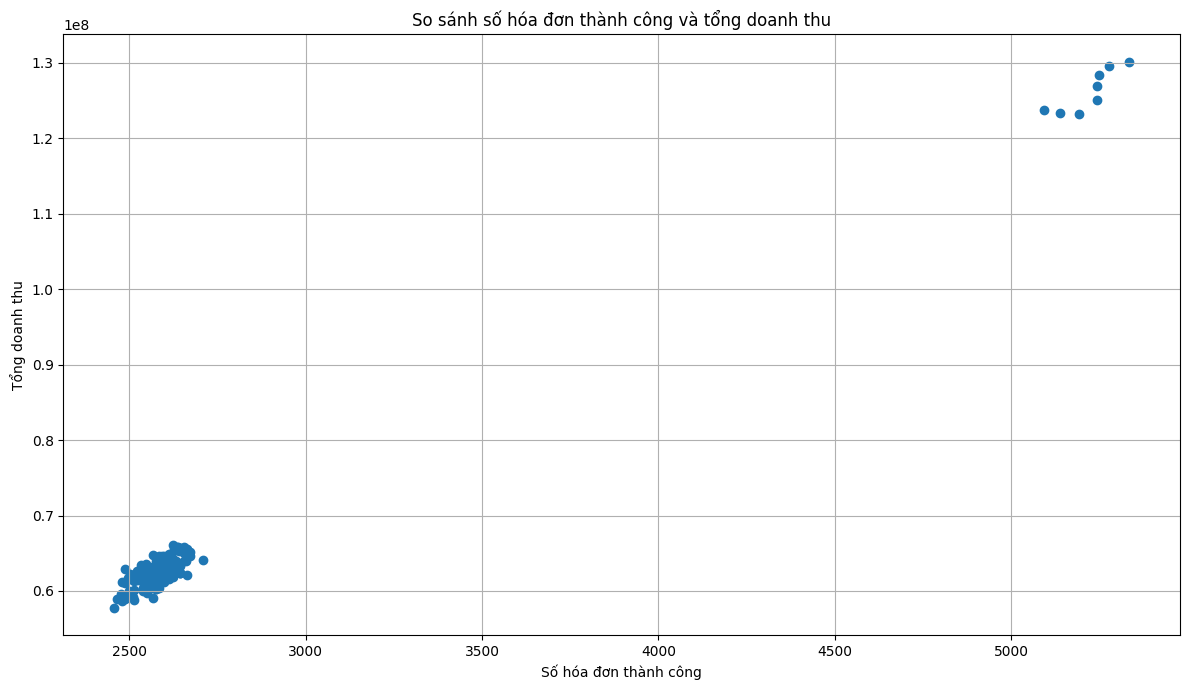

In [38]:
#Vẽ biểu đồ số hóa đơn và doanh thu

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.scatter(
    conversion_kpi["Hoa_don_thanh_cong"],
    conversion_kpi["Tong_doanh_thu"]
)

plt.title("So sánh số hóa đơn thành công và tổng doanh thu")
plt.xlabel("Số hóa đơn thành công")
plt.ylabel("Tổng doanh thu")
plt.grid(True)

plt.tight_layout()
plt.show()

In [39]:
#Tạo bảng “chất lượng giao dịch”

transaction_quality = conversion_kpi.copy()

# Xếp hạng từng chỉ tiêu
transaction_quality["Rank_Chuyen_doi"] = (
    transaction_quality["Ty_le_chuyen_doi"]
    .rank(ascending=False, method="min")
)

transaction_quality["Rank_Gia_tri_HD"] = (
    transaction_quality["Doanh_thu_TB_hoa_don"]
    .rank(ascending=False, method="min")
)

# Tổng thứ hạng
transaction_quality["Tong_xep_hang"] = (
    transaction_quality["Rank_Chuyen_doi"]
    + transaction_quality["Rank_Gia_tri_HD"]
)

# Xếp hạng tổng hợp
transaction_quality = transaction_quality.sort_values(
    "Tong_xep_hang"
)

print("===== TOP 10 NHÂN VIÊN VỀ CHẤT LƯỢNG GIAO DỊCH =====")

print(
    transaction_quality[
        [
            "Nhan_vien",
            "Ty_le_chuyen_doi",
            "Doanh_thu_TB_hoa_don",
            "Tong_doanh_thu",
            "Rank_Chuyen_doi",
            "Rank_Gia_tri_HD",
            "Tong_xep_hang"
        ]
    ].head(10).to_string(index=False)
)

===== TOP 10 NHÂN VIÊN VỀ CHẤT LƯỢNG GIAO DỊCH =====
     Nhan_vien  Ty_le_chuyen_doi  Doanh_thu_TB_hoa_don  Tong_doanh_thu  Rank_Chuyen_doi  Rank_Gia_tri_HD  Tong_xep_hang
Phạm Thanh Mai         81.510255          25201.299775     66103009.31              2.0              2.0            4.0
   Lê Hữu Dũng         81.013825          24986.627698     65889737.24             11.0              7.0           18.0
  Dương Thị Hà         80.985915          24833.694945     65685123.13             12.0             17.0           29.0
Lê Thanh Trang         80.655035          24990.250304     65849309.55             25.0              6.0           31.0
 Nguyễn Văn Hà         80.733083          24820.294020     63961897.69             18.0             18.0           36.0
 Huỳnh Đức Nam         81.018093          24696.742593     65248793.93             10.0             26.0           36.0
   Đỗ Gia Linh         81.032864          24671.441390     63874361.76              8.0             31.0   

In [40]:
#Tạo bảng tổng hợp cuối cùng

problem5_final = transaction_quality[
    [
        "Nhan_vien",
        "Tong_hoa_don",
        "Hoa_don_thanh_cong",
        "Ty_le_chuyen_doi",
        "Tong_doanh_thu",
        "Doanh_thu_TB_hoa_don",
        "Tong_xep_hang"
    ]
].copy()

problem5_final = problem5_final.sort_values(
    "Tong_xep_hang"
)

print("===== BẢNG TỔNG HỢP PROBLEM 5 =====")

print(
    problem5_final.head(20).to_string(index=False)
)

===== BẢNG TỔNG HỢP PROBLEM 5 =====
       Nhan_vien  Tong_hoa_don  Hoa_don_thanh_cong  Ty_le_chuyen_doi  Tong_doanh_thu  Doanh_thu_TB_hoa_don  Tong_xep_hang
  Phạm Thanh Mai          3218                2623         81.510255     66103009.31          25201.299775            4.0
     Lê Hữu Dũng          3255                2637         81.013825     65889737.24          24986.627698           18.0
    Dương Thị Hà          3266                2645         80.985915     65685123.13          24833.694945           29.0
  Lê Thanh Trang          3267                2635         80.655035     65849309.55          24990.250304           31.0
   Nguyễn Văn Hà          3192                2577         80.733083     63961897.69          24820.294020           36.0
   Huỳnh Đức Nam          3261                2642         81.018093     65248793.93          24696.742593           36.0
     Đỗ Gia Linh          3195                2589         81.032864     63874361.76          24671.441390    

In [41]:
#Xuất bảng Problem 5 ra Excel

file_output = "/content/Problem5_KPI_NhanVien.xlsx"

problem5_final.to_excel(
    file_output,
    index=False
)

print("Đã xuất file thành công!")
print("File:", file_output)

Đã xuất file thành công!
File: /content/Problem5_KPI_NhanVien.xlsx


In [42]:
#Xuất bảng Problem 4

file_output_4 = "/content/Problem4_KPI_NhanVien.xlsx"

kpi_final.to_excel(
    file_output_4,
    index=False
)

print("Đã xuất file Problem 4 thành công!")
print("File:", file_output_4)

Đã xuất file Problem 4 thành công!
File: /content/Problem4_KPI_NhanVien.xlsx
